In [20]:
# imports 
import pandas as pd
import os 
import sys
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
from src.data_loader import load_data, load_data_from_file
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, learning_curve
from sklearn.feature_selection import RFECV


from sklearn.model_selection import (
    cross_validate,
    cross_val_score,
    KFold,
    StratifiedKFold,
)
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
import xgboost as xgb
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import validation_curve
from sklearn.metrics import roc_auc_score, average_precision_score
import umap


# Data Import

In [29]:
print(f"Python version: {sys.version}")

Python version: 3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]


In [21]:
location = '../data/raw/'
df = load_data_from_file(file_path=os.path.join(location, 'SantanderCustomerSatisfaction.csv'))

def tweak_df(df):
    df = df.copy()
    df['target'] = df['target'].astype('category')
    return df
df = tweak_df(df)


Loading dataset from file: ../data/raw/SantanderCustomerSatisfaction.csv...


# Train test split 

In [22]:
(
    df_train,
    df_test,
    y_train,
    y_test,
) = train_test_split(
    df.drop(columns=['target']),
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target'],
)

def run_cv(estimator, X, y, cv, verbose=3):
    return cross_validate(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=("roc_auc", "average_precision"),
        return_estimator=True,
        return_indices=True,
        return_train_score=True,
        verbose=verbose,
    )
    
def print_test_scores(cv_results, scorings=("test_roc_auc", "test_average_precision")):
    for score in scorings:
        print(
            f"mean {score:30s} score = {cv_results[score].mean():.5f} +/- {cv_results[score].std():.5f}"
        )
        
def print_train_scores(cv_results, scorings=("train_roc_auc", "train_average_precision")):
    for score in scorings:
        print(
            f"mean {score:30s} score = {cv_results[score].mean():.5f} +/- {cv_results[score].std():.5f}"
        )
    

# Defining standard classifier

In [23]:
p_xgb = make_pipeline(
    xgb.XGBClassifier(   
    random_state=42,   
)
)

# Learning Curve

In [6]:
def _plot_learning_curve(scoring):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=p_xgb.named_steps['xgbclassifier'], X=df_train, y=y_train, cv=4, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10))

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, color='blue', marker='o', label=f'Training {scoring}')
    plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
    plt.plot(train_sizes, test_mean, color='green', marker='+', label=f'Validation {scoring}')
    plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
    plt.title('Learning Curves')
    plt.xlabel('Training set size')
    plt.ylabel(scoring)
    plt.grid()
    plt.legend(loc='lower right')
    plt.show()

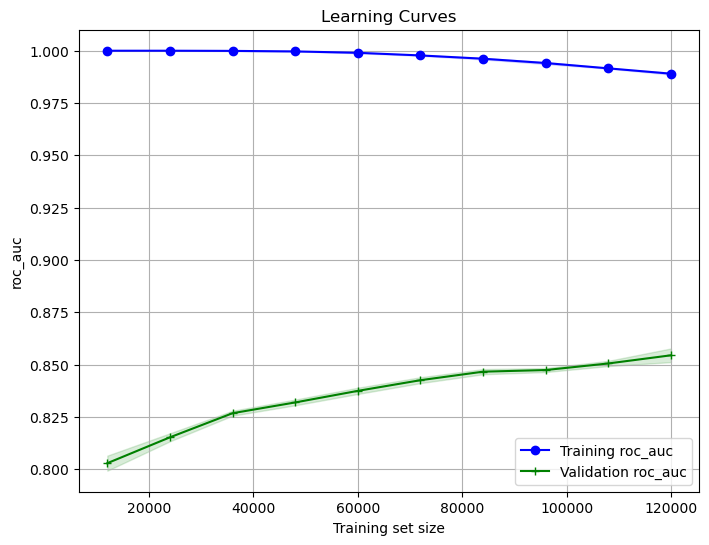

In [7]:
_plot_learning_curve('roc_auc')

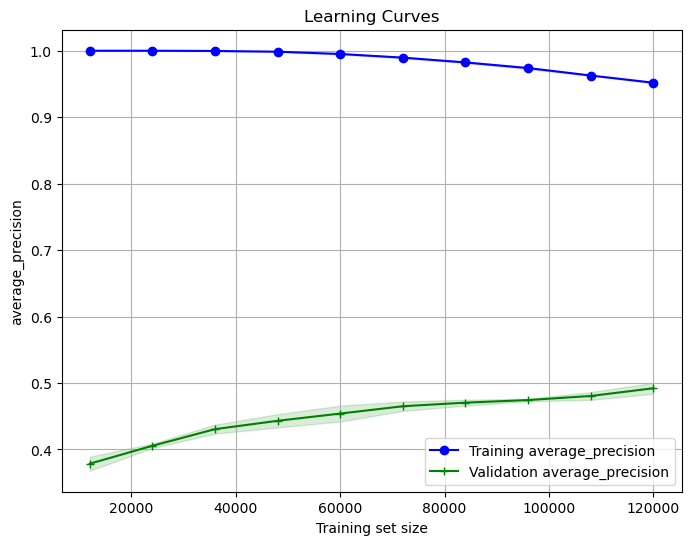

In [8]:
_plot_learning_curve('average_precision')

- The model is overfitting, but the bigger issue is that validation average precision is low and plateauing. That points to model/feature limitations rather than just a data shortage.
- Adding more data does help (validation performance improves), but the gap remains significant.
- The absolute validation performance is low (average precision ~0.46), suggesting the model struggles to rank positive samples well compared to negatives.

# Data Compression

In [13]:
pca = PCA(n_components=0.99)  # have enough components to explain 99% variance
X_train_pca = pca.fit_transform(df_train)

print("Number of components for 99% variance:", pca.n_components_)


Number of components for 99% variance: 144


In [15]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, X_train_pca, y_train, cv=cv)

[CV] END  average_precision: (train=0.909, test=0.386) roc_auc: (train=0.979, test=0.806) total time=  15.8s
[CV] END  average_precision: (train=0.912, test=0.383) roc_auc: (train=0.978, test=0.808) total time=  15.3s
[CV] END  average_precision: (train=0.914, test=0.381) roc_auc: (train=0.980, test=0.802) total time=  11.4s
[CV] END  average_precision: (train=0.910, test=0.387) roc_auc: (train=0.978, test=0.807) total time=  10.8s


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:   55.4s finished


In [18]:
print_train_scores(cv_results)
print_test_scores(cv_results)

mean train_roc_auc                  score = 0.97868 +/- 0.00059
mean train_average_precision        score = 0.91139 +/- 0.00194
mean test_roc_auc                   score = 0.80573 +/- 0.00228
mean test_average_precision         score = 0.38432 +/- 0.00224


In [19]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_train, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.954, test=0.487) roc_auc: (train=0.990, test=0.849) total time=  25.5s
[CV] END  average_precision: (train=0.950, test=0.487) roc_auc: (train=0.989, test=0.853) total time=  26.6s
[CV] END  average_precision: (train=0.953, test=0.490) roc_auc: (train=0.990, test=0.855) total time=  22.8s
[CV] END  average_precision: (train=0.953, test=0.493) roc_auc: (train=0.990, test=0.857) total time=  25.4s
mean train_roc_auc                  score = 0.98943 +/- 0.00047
mean train_average_precision        score = 0.95244 +/- 0.00164
mean test_roc_auc                   score = 0.85369 +/- 0.00300
mean test_average_precision         score = 0.48941 +/- 0.00248


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  1.7min finished


In [28]:
lr_pipeline_pca = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000)
)

cv_results = run_cv(lr_pipeline_pca, X_train_pca, y_train, cv=cv)

[CV] END .................................................... total time=   1.2s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   1.3s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    7.2s finished


In [30]:
print_train_scores(cv_results)

mean train_roc_auc                  score = 0.82205 +/- 0.00041
mean train_average_precision        score = 0.42718 +/- 0.00199


In [29]:
print_test_scores(cv_results)

mean test_roc_auc                   score = 0.81995 +/- 0.00180
mean test_average_precision         score = 0.42284 +/- 0.00765


The performance is dropping when using PCA so i will not use it in the following tasks

# Feature Engineering

## Binning

In [13]:
df_binned = df.drop(columns=['target']).apply(lambda x: pd.cut(x, bins=200, labels=False))


In [14]:
(
    df_train_binned,
    df_test_binned,
    y_train_binned,
    y_test_binned,
) = train_test_split(
    df_binned,
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target'],
)

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_train_binned, y_train_binned, cv=cv)

[CV] END .................................................... total time=  22.7s
[CV] END .................................................... total time=  21.1s
[CV] END .................................................... total time=  18.0s
[CV] END .................................................... total time=  16.5s
[CV] END .................................................... total time=  21.9s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.7min finished


In [16]:
print_train_scores(cv_results)

mean train_roc_auc                  score = 0.98328 +/- 0.00046
mean train_average_precision        score = 0.92883 +/- 0.00075


In [17]:
print_test_scores(cv_results)

mean test_roc_auc                   score = 0.87269 +/- 0.00304
mean test_average_precision         score = 0.53745 +/- 0.01110


Binning improved the mean test_average_precision just a little bit but nothing dramatic

## Row Level statistics

In [5]:
df_row_stats = df_train.copy()
df_row_stats['row_mean'] = df_row_stats.mean(axis=1)
df_row_stats['row_std'] = df_row_stats.std(axis=1)
df_row_stats['row_min'] = df_row_stats.min(axis=1)
df_row_stats['row_max'] = df_row_stats.max(axis=1)
df_row_stats['row_median'] = df_row_stats.median(axis=1)
df_row_stats['row_sum'] = df_row_stats.sum(axis=1)
df_row_stats['row_kurtosis'] = df_row_stats.kurtosis(axis=1)
df_row_stats['row_skew'] = df_row_stats.skew(axis=1)


In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_row_stats, y_train, cv=cv)

[CV] END .................................................... total time=  55.4s
[CV] END .................................................... total time=  58.5s
[CV] END .................................................... total time=  56.6s
[CV] END .................................................... total time=  52.4s
[CV] END .................................................... total time=  51.9s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.6min finished


In [25]:
print_train_scores(cv_results)

mean train_roc_auc                  score = 0.98391 +/- 0.00027
mean train_average_precision        score = 0.93224 +/- 0.00091


In [26]:
print_test_scores(cv_results)

mean test_roc_auc                   score = 0.87244 +/- 0.00307
mean test_average_precision         score = 0.53890 +/- 0.00618


The dataset contains information about customers, so its expected to see some kind of customers clusters in the data. I will try now Gaussian mixture models clustering and use the clusters as another feature in the data

## MiniBatchKmeans

In [ ]:
p_xgb = make_pipeline(
    xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
    )
)

df_train_clusters =  df_row_stats.copy()
p_minibatch = make_pipeline(
    StandardScaler(),
    MiniBatchKMeans(
        n_clusters=2,
        init='k-means++',
        n_init=10,
        random_state=42,
        batch_size=10000   
    )
)

cluster_labels = p_minibatch.fit_predict(df_train_clusters)

df_train_clusters['clusters'] = cluster_labels

In [127]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_train_clusters, y_train, cv=cv)

[CV] END .................................................... total time=  56.3s
[CV] END .................................................... total time=  58.8s
[CV] END .................................................... total time=  59.3s
[CV] END .................................................... total time= 1.0min
[CV] END .................................................... total time=  57.2s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.9min finished


In [128]:
print_train_scores(cv_results)

mean train_roc_auc                  score = 0.98403 +/- 0.00024
mean train_average_precision        score = 0.93275 +/- 0.00043


In [129]:
print_test_scores(cv_results)

mean test_roc_auc                   score = 0.87257 +/- 0.00280
mean test_average_precision         score = 0.54026 +/- 0.00934


The dataset is highly imbalanced, we see that adding row level statistic gave a slight improvement in the metrics. Adding clustering methods didnt help that much (maybe another clustering method could help really as its expected to see clusters of customers). The dataset is highly imbalanced so thats why the ap is dropping in test data a lot. Data augmentation would help here. I will consider taking an oversampling method to augment the positive classes after hyperparameter tuning.

# Complete Pipeline

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

class KMeansTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=2, batch_size=10000, random_state=42):
        self.n_clusters = n_clusters
        self.batch_size = batch_size
        self.random_state = random_state
        self.kmeans = None

    def fit(self, X, y=None):
        from sklearn.cluster import MiniBatchKMeans
        self.kmeans = MiniBatchKMeans(
            n_clusters=self.n_clusters,
            batch_size=self.batch_size,
            random_state=self.random_state
        )
        self.kmeans.fit(X)
        return self

    def transform(self, X):
        # Return cluster labels as a single-column array
        return np.column_stack([X, self.kmeans.predict(X)])


In [ ]:
p_xgb_final = make_pipeline(
    #'''StandardScaler(),
    #MiniBatchKMeans(
    #    n_clusters=2,
    #    init='k-means++',
    #    n_init=10,
    #    random_state=42,
    #    batch_size=10000   
    #),'''
    xgb.XGBClassifier(
        random_state=42,
    )
)
def _plot_validation_curve(param_name, param_range, scorings): 
    n_scoring = len(scorings)
    fig, axes = plt.subplots(1, n_scoring, figsize=(7 * n_scoring, 5), sharey=False)

    if n_scoring == 1:
        axes = [axes]  
    
    for ax, scoring in zip(axes, scorings):
        train_scores, test_scores = validation_curve(
            p_xgb_final,            
            X=df_train,             
            y=y_train,              
            param_name=param_name,
            param_range=param_range,
            scoring=scoring,      
            cv=3,
            verbose=3         
        )

        # mean & std
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        # plot
        ax.plot(param_range, train_mean, label="Train score", color="blue")
        ax.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
        ax.plot(param_range, test_mean, label="Validation score", color="green")
        ax.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")
        
        ax.set_xlabel(param_name)
        ax.set_ylabel(scoring)
        ax.set_title(f"Validation Curve: {param_name} ({scoring})")
        ax.legend()

    plt.tight_layout()
    plt.show()



improving this parameter wont help because there is no variation. I will investigate xgboost parameters now 

[CV] END xgbclassifier__max_depth=2;, score=(train=0.877, test=0.849) total time=  18.3s
[CV] END xgbclassifier__max_depth=3;, score=(train=0.907, test=0.858) total time=  22.9s
[CV] END xgbclassifier__max_depth=4;, score=(train=0.939, test=0.866) total time=  30.7s
[CV] END xgbclassifier__max_depth=5;, score=(train=0.968, test=0.868) total time=  48.9s
[CV] END xgbclassifier__max_depth=6;, score=(train=0.989, test=0.869) total time=  40.2s
[CV] END xgbclassifier__max_depth=7;, score=(train=0.998, test=0.864) total time=  49.7s
[CV] END xgbclassifier__max_depth=2;, score=(train=0.875, test=0.852) total time=  18.6s
[CV] END xgbclassifier__max_depth=3;, score=(train=0.907, test=0.862) total time=  23.1s
[CV] END xgbclassifier__max_depth=4;, score=(train=0.937, test=0.869) total time=  25.5s
[CV] END xgbclassifier__max_depth=5;, score=(train=0.967, test=0.872) total time=  31.5s
[CV] END xgbclassifier__max_depth=6;, score=(train=0.989, test=0.870) total time=  37.4s
[CV] END xgbclassifie

[Parallel(n_jobs=1)]: Done  18 out of  18 | elapsed:  9.7min finished


[CV] END xgbclassifier__max_depth=2;, score=(train=0.565, test=0.483) total time=  17.1s
[CV] END xgbclassifier__max_depth=3;, score=(train=0.656, test=0.505) total time=  19.4s
[CV] END xgbclassifier__max_depth=4;, score=(train=0.758, test=0.521) total time=  23.7s
[CV] END xgbclassifier__max_depth=5;, score=(train=0.865, test=0.523) total time=  29.9s
[CV] END xgbclassifier__max_depth=6;, score=(train=0.952, test=0.529) total time=  34.9s
[CV] END xgbclassifier__max_depth=7;, score=(train=0.992, test=0.521) total time=  46.1s
[CV] END xgbclassifier__max_depth=2;, score=(train=0.560, test=0.490) total time=  23.8s
[CV] END xgbclassifier__max_depth=3;, score=(train=0.654, test=0.514) total time=  27.8s
[CV] END xgbclassifier__max_depth=4;, score=(train=0.757, test=0.524) total time=  37.4s
[CV] END xgbclassifier__max_depth=5;, score=(train=0.866, test=0.532) total time=  34.4s
[CV] END xgbclassifier__max_depth=6;, score=(train=0.952, test=0.530) total time=  45.1s
[CV] END xgbclassifie

[Parallel(n_jobs=1)]: Done  18 out of  18 | elapsed: 10.5min finished


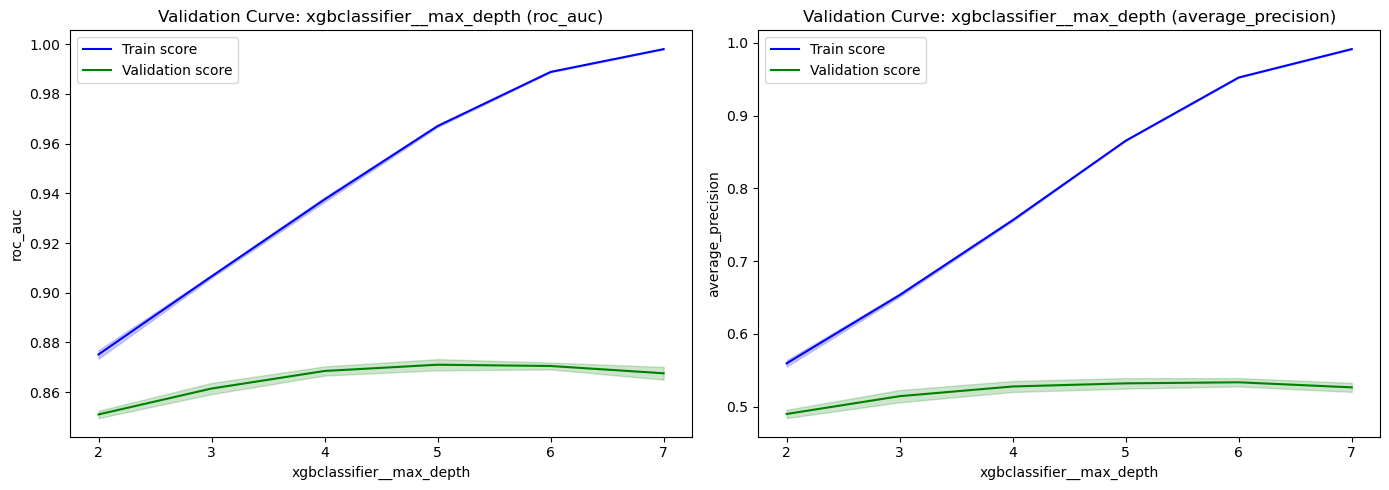

In [164]:
param_name = "xgbclassifier__max_depth"
param_range = np.arange(2, 8)

_plot_validation_curve(param_name, param_range, scorings=("roc_auc", "average_precision"))


[CV] END xgbclassifier__learning_rate=0.01;, score=(train=0.879, test=0.794) total time=  42.1s
[CV] END xgbclassifier__learning_rate=0.05;, score=(train=0.970, test=0.860) total time=  47.7s
[CV] END xgbclassifier__learning_rate=0.1;, score=(train=0.989, test=0.869) total time=  49.8s
[CV] END xgbclassifier__learning_rate=0.2;, score=(train=0.998, test=0.865) total time=  48.7s
[CV] END xgbclassifier__learning_rate=0.3;, score=(train=1.000, test=0.857) total time=  51.7s
[CV] END xgbclassifier__learning_rate=0.01;, score=(train=0.879, test=0.802) total time=  40.0s
[CV] END xgbclassifier__learning_rate=0.05;, score=(train=0.969, test=0.862) total time=  39.7s
[CV] END xgbclassifier__learning_rate=0.1;, score=(train=0.989, test=0.870) total time=  38.1s
[CV] END xgbclassifier__learning_rate=0.2;, score=(train=0.998, test=0.868) total time=  37.9s
[CV] END xgbclassifier__learning_rate=0.3;, score=(train=1.000, test=0.858) total time=  37.4s
[CV] END xgbclassifier__learning_rate=0.01;, s

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed: 11.0min finished


[CV] END xgbclassifier__learning_rate=0.01;, score=(train=0.640, test=0.380) total time=  54.3s
[CV] END xgbclassifier__learning_rate=0.05;, score=(train=0.882, test=0.511) total time=  49.1s
[CV] END xgbclassifier__learning_rate=0.1;, score=(train=0.952, test=0.529) total time=  53.0s
[CV] END xgbclassifier__learning_rate=0.2;, score=(train=0.990, test=0.512) total time=  58.4s
[CV] END xgbclassifier__learning_rate=0.3;, score=(train=0.999, test=0.493) total time=  47.3s
[CV] END xgbclassifier__learning_rate=0.01;, score=(train=0.639, test=0.381) total time=  51.4s
[CV] END xgbclassifier__learning_rate=0.05;, score=(train=0.881, test=0.506) total time=  44.8s
[CV] END xgbclassifier__learning_rate=0.1;, score=(train=0.952, test=0.530) total time=  44.3s
[CV] END xgbclassifier__learning_rate=0.2;, score=(train=0.990, test=0.517) total time=  40.3s
[CV] END xgbclassifier__learning_rate=0.3;, score=(train=0.998, test=0.497) total time=  39.1s
[CV] END xgbclassifier__learning_rate=0.01;, s

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed: 11.4min finished


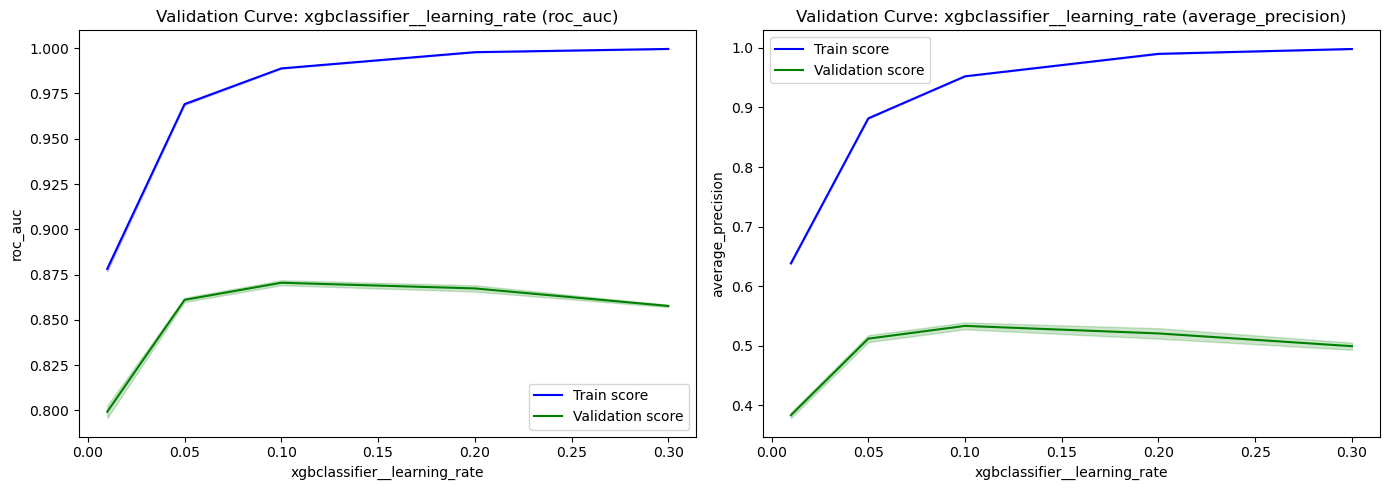

In [165]:
param_name = "xgbclassifier__learning_rate"
param_range = [0.01, 0.05, 0.1, 0.2, 0.3]

_plot_validation_curve(param_name, param_range, scorings=("roc_auc", "average_precision"))

[CV] END xgbclassifier__n_estimators=50;, score=(train=0.927, test=0.825) total time=  10.4s
[CV] END xgbclassifier__n_estimators=100;, score=(train=0.965, test=0.852) total time=  19.1s
[CV] END xgbclassifier__n_estimators=200;, score=(train=0.989, test=0.869) total time=  36.9s
[CV] END xgbclassifier__n_estimators=300;, score=(train=0.996, test=0.874) total time=  52.5s
[CV] END xgbclassifier__n_estimators=400;, score=(train=0.999, test=0.876) total time= 1.2min
[CV] END xgbclassifier__n_estimators=50;, score=(train=0.925, test=0.827) total time=   9.8s
[CV] END xgbclassifier__n_estimators=100;, score=(train=0.964, test=0.853) total time=  18.0s
[CV] END xgbclassifier__n_estimators=200;, score=(train=0.989, test=0.870) total time=  36.2s
[CV] END xgbclassifier__n_estimators=300;, score=(train=0.996, test=0.876) total time= 1.1min
[CV] END xgbclassifier__n_estimators=400;, score=(train=0.998, test=0.878) total time= 1.5min
[CV] END xgbclassifier__n_estimators=50;, score=(train=0.926, 

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed: 11.3min finished


[CV] END xgbclassifier__n_estimators=50;, score=(train=0.748, test=0.429) total time=  20.9s
[CV] END xgbclassifier__n_estimators=100;, score=(train=0.865, test=0.487) total time=  22.4s
[CV] END xgbclassifier__n_estimators=200;, score=(train=0.952, test=0.529) total time= 1.4min
[CV] END xgbclassifier__n_estimators=300;, score=(train=0.982, test=0.542) total time=  55.3s
[CV] END xgbclassifier__n_estimators=400;, score=(train=0.994, test=0.550) total time= 1.6min
[CV] END xgbclassifier__n_estimators=50;, score=(train=0.749, test=0.425) total time=  12.3s
[CV] END xgbclassifier__n_estimators=100;, score=(train=0.865, test=0.487) total time=  18.3s
[CV] END xgbclassifier__n_estimators=200;, score=(train=0.952, test=0.530) total time=  37.0s
[CV] END xgbclassifier__n_estimators=300;, score=(train=0.982, test=0.545) total time= 1.2min
[CV] END xgbclassifier__n_estimators=400;, score=(train=0.993, test=0.549) total time= 2.0min
[CV] END xgbclassifier__n_estimators=50;, score=(train=0.746, 

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed: 14.2min finished


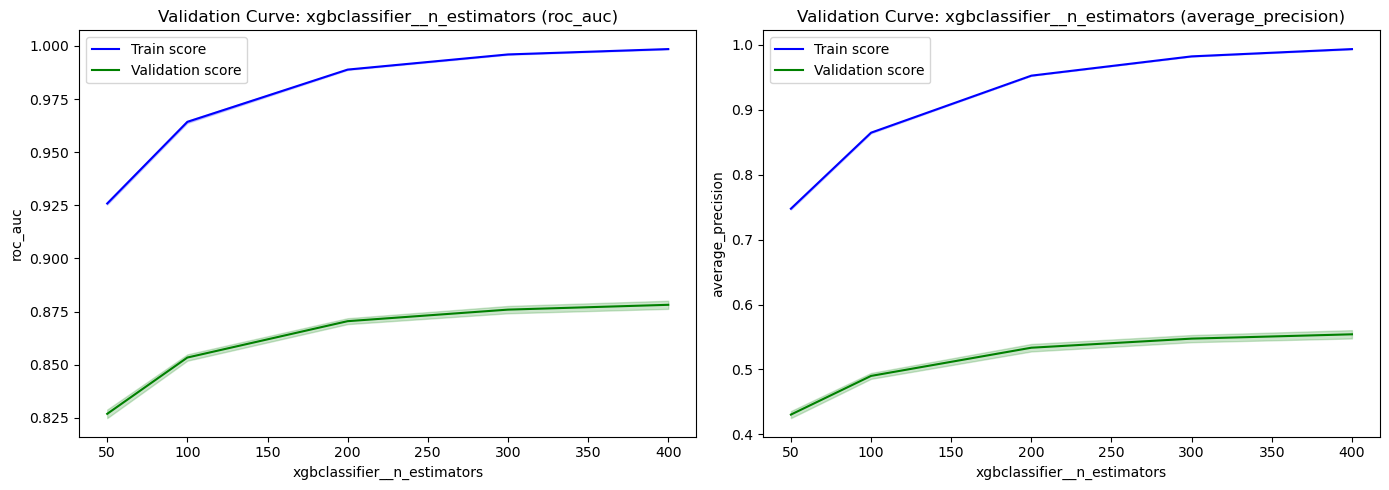

In [166]:
param_name = "xgbclassifier__n_estimators"
param_range = [50, 100, 200, 300, 400]

_plot_validation_curve(param_name, param_range, scorings=("roc_auc", "average_precision"))

C:\Users\marou\AppData\Local\Temp\ipykernel_13028\3435192268.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale_ratio = (y_train.value_counts()[0] / y_train.value_counts()[1])
C:\Users\marou\AppData\Local\Temp\ipykernel_13028\3435192268.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale_ratio = (y_train.value_counts()[0] / y_train.value_counts()[1])


Suggested scale_pos_weight: 8.95148650329643
[CV] END xgbclassifier__scale_pos_weight=4;, score=(train=0.990, test=0.864) total time=  48.5s
[CV] END xgbclassifier__scale_pos_weight=8;, score=(train=0.989, test=0.862) total time=  42.6s
[CV] END xgbclassifier__scale_pos_weight=17;, score=(train=0.989, test=0.855) total time=  41.1s
[CV] END xgbclassifier__scale_pos_weight=44;, score=(train=0.988, test=0.834) total time=  42.4s
[CV] END xgbclassifier__scale_pos_weight=4;, score=(train=0.990, test=0.869) total time=  44.1s
[CV] END xgbclassifier__scale_pos_weight=8;, score=(train=0.989, test=0.864) total time=  46.5s
[CV] END xgbclassifier__scale_pos_weight=17;, score=(train=0.989, test=0.858) total time=  39.6s
[CV] END xgbclassifier__scale_pos_weight=44;, score=(train=0.988, test=0.841) total time=  43.8s
[CV] END xgbclassifier__scale_pos_weight=4;, score=(train=0.989, test=0.871) total time=  55.0s
[CV] END xgbclassifier__scale_pos_weight=8;, score=(train=0.989, test=0.864) total time

[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:  8.9min finished


[CV] END xgbclassifier__scale_pos_weight=4;, score=(train=0.943, test=0.519) total time=  40.5s
[CV] END xgbclassifier__scale_pos_weight=8;, score=(train=0.935, test=0.514) total time=  45.7s
[CV] END xgbclassifier__scale_pos_weight=17;, score=(train=0.929, test=0.498) total time=  45.1s
[CV] END xgbclassifier__scale_pos_weight=44;, score=(train=0.919, test=0.456) total time=  36.9s
[CV] END xgbclassifier__scale_pos_weight=4;, score=(train=0.944, test=0.527) total time=  45.5s
[CV] END xgbclassifier__scale_pos_weight=8;, score=(train=0.938, test=0.516) total time=  45.6s
[CV] END xgbclassifier__scale_pos_weight=17;, score=(train=0.931, test=0.500) total time=  42.0s
[CV] END xgbclassifier__scale_pos_weight=44;, score=(train=0.917, test=0.469) total time=  41.2s
[CV] END xgbclassifier__scale_pos_weight=4;, score=(train=0.945, test=0.547) total time=  36.8s
[CV] END xgbclassifier__scale_pos_weight=8;, score=(train=0.937, test=0.529) total time=  41.1s
[CV] END xgbclassifier__scale_pos_we

[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:  9.0min finished


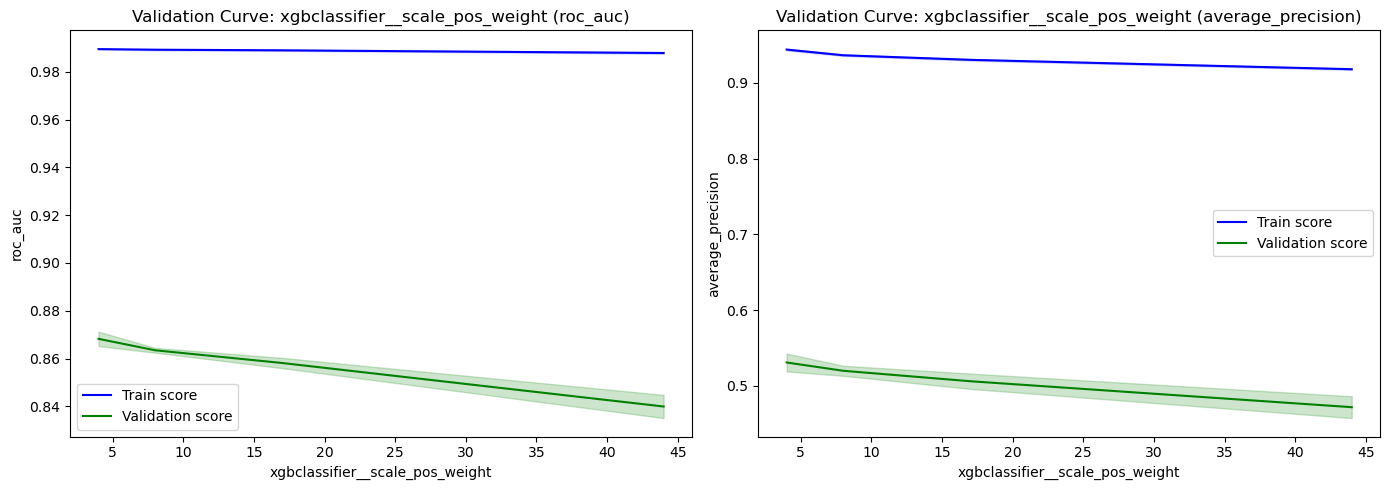

In [9]:
scale_ratio = (y_train.value_counts()[0] / y_train.value_counts()[1])
print("Suggested scale_pos_weight:", scale_ratio)

param_name = "xgbclassifier__scale_pos_weight"
param_range = [
    max(1, int(scale_ratio * 0.5)), 
    int(scale_ratio), 
    int(scale_ratio * 2), 
    int(scale_ratio * 5)
]

_plot_validation_curve(param_name, param_range, scorings=("roc_auc", "average_precision"))

## Overall Conclusion

the model is overfitting across multiple hyperparameters, as evidenced by the large and increasing gap between the training and validation scores in most of the plots. The most significant overfitting seems to be related to **max_depth**, which plateaus on the validation set after a certain point.  

The best-performing hyperparameter values identified from these plots are:

- **max_depth**: Around 6  
- **n_estimators**: A higher value, but need to consider the increasing gap between training and validation scores.  
- **learning_rate**: Around 0.1  
- **scale_pos_weight**: A low value from the tested range  

Even regularization methods wont bring too much due the high imbalance in the dataset. I will first try data augmentation and then run a hyperparameter tuning process 

In [52]:
p_xgb = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
    )
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_train, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.947, test=0.490) roc_auc: (train=0.988, test=0.853) total time=  22.1s
[CV] END  average_precision: (train=0.943, test=0.493) roc_auc: (train=0.987, test=0.853) total time=  19.8s
[CV] END  average_precision: (train=0.944, test=0.496) roc_auc: (train=0.987, test=0.859) total time=  21.2s
[CV] END  average_precision: (train=0.946, test=0.487) roc_auc: (train=0.987, test=0.855) total time=  19.8s
[CV] END  average_precision: (train=0.944, test=0.482) roc_auc: (train=0.988, test=0.854) total time=  19.1s
mean train_roc_auc                  score = 0.98751 +/- 0.00030
mean train_average_precision        score = 0.94485 +/- 0.00144
mean test_roc_auc                   score = 0.85477 +/- 0.00211
mean test_average_precision         score = 0.48939 +/- 0.00487


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.7min finished


# Feature Importance 

In [ ]:
p_xgb.fit(df_train, y_train)
xgb_model = p_xgb.named_steps['xgbclassifier']

# Get feature importances by gain
importances = xgb_model.get_booster().get_score(importance_type='gain')

# Convert to sorted DataFrame


,feature,importance
81,var_81,66.265114
139,var_139,55.683319
110,var_110,54.686020
12,var_12,51.223324
53,var_53,46.539772
174,var_174,44.313236
146,var_146,42.548405
6,var_6,40.182384
80,var_80,39.637447
76,var_76,38.739281


In [24]:
importances_df = pd.DataFrame({
    'feature': list(importances.keys()),
    'importance': list(importances.values())
}).sort_values(by='importance', ascending=False)

importances_df["importance"] = (
    importances_df["importance"] / importances_df["importance"].sum() * 100
)

# sort descending
importances_df = importances_df.sort_values(by="importance", ascending=False)

# round for readability (optional)
importances_df["importance"] = importances_df["importance"].round(2)

importances_df.head(20)

NameError: name 'importances' is not defined

In [57]:
importances_df['feature'].head(20).to_list()

['var_81',
 'var_139',
 'var_110',
 'var_12',
 'var_53',
 'var_174',
 'var_146',
 'var_6',
 'var_80',
 'var_76',
 'var_109',
 'var_26',
 'var_133',
 'var_0',
 'var_190',
 'var_166',
 'var_179',
 'var_22',
 'var_44',
 'var_21']

In [ ]:
top_20 = ['var_81', 'var_139', 'var_110','var_12', 'var_53', 'var_174', 'var_146', 'var_6', 'var_80', 'var_76',
          'var_109', 'var_26', 'var_133', 'var_0', 'var_190', 'var_166', 'var_179', 'var_22', 'var_44', 'var_21']

# Trying Feature Engineering techniques

In [260]:
def augment_positive_only_independent(df_train: pd.DataFrame, y_train: pd.Series, t: int = 4):
    xs = []

    # --- Positive class augmentation ---
    mask_pos = y_train > 0
    x_pos = df_train[mask_pos]

    means = x_pos.mean()
    stds = x_pos.std()

    n_pos = x_pos.shape[0]

    for _ in range(t):
        x_syn = np.random.normal(loc=means, scale=stds, size=(n_pos, x_pos.shape[1]))
        xs.append(x_syn)

    # --- Stack synthetic positives ---
    xs = np.vstack(xs) if xs else np.empty((0, df_train.shape[1]))
    ys = np.ones(xs.shape[0])

    # --- Rebuild dataset ---
    df_syn = pd.DataFrame(xs, columns=df_train.columns)
    y_syn = pd.Series(ys, name=y_train.name)

    df_aug = pd.concat([df_train, df_syn], ignore_index=True)
    y_aug = pd.concat([y_train.reset_index(drop=True), y_syn.reset_index(drop=True)], ignore_index=True)

    return df_aug, y_aug


def flag_duplicates(X, features, new_col_suffix='_FE'):
    df = X.copy()
    
    for col in features:
        counts = df[col].value_counts()
        new_col = col + new_col_suffix
        df[new_col] = df[col].map(counts)
        
        # Downcast for memory efficiency
        if counts.max() <= 255:
            df[new_col] = df[new_col].astype("uint8")
        elif counts.max() <= 65535:
            df[new_col] = df[new_col].astype("uint16")
        else:
            df[new_col] = df[new_col].astype("uint32")
    return df

def flag_duplicates(df, features, new_col_suffix='_FE'):
    df = df.copy()
    new_cols = {}
    
    for col in features:
        counts = df[col].value_counts()
        new_col = col + new_col_suffix
        new_cols[new_col] = df[col].map(counts).astype('uint32')  # choose appropriate dtype

    # Add all new columns at once
    df = pd.concat([df, pd.DataFrame(new_cols)], axis=1)
    return df

#df_train_aug,y_train_aug = augment_positive_only_independent(df_train, y_train.astype(int), t=4)
df_train_flagged = flag_duplicates(df_train, df_train.columns.tolist())

In [261]:
best_pars = {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0, 'n_estimators': 450}

p_xgb_aug = make_pipeline(
    xgb.XGBClassifier(
        **best_pars,
        random_state=42,
    )
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb_aug, df_train_flagged, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.918, test=0.582) roc_auc: (train=0.982, test=0.888) total time= 1.7min
[CV] END  average_precision: (train=0.916, test=0.581) roc_auc: (train=0.982, test=0.890) total time= 1.6min
[CV] END  average_precision: (train=0.916, test=0.610) roc_auc: (train=0.982, test=0.896) total time= 1.6min
[CV] END  average_precision: (train=0.918, test=0.576) roc_auc: (train=0.982, test=0.888) total time= 1.5min
[CV] END  average_precision: (train=0.916, test=0.591) roc_auc: (train=0.982, test=0.890) total time= 1.5min
mean train_roc_auc                  score = 0.98172 +/- 0.00011
mean train_average_precision        score = 0.91697 +/- 0.00116
mean test_roc_auc                   score = 0.89055 +/- 0.00305
mean test_average_precision         score = 0.58807 +/- 0.01226


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  8.0min finished


In [250]:
best_fold_idx = np.argmax(cv_results['test_roc_auc'])
best_model = cv_results['estimator'][best_fold_idx]

print(f"Selected fold {best_fold_idx+1} as best model based on test_roc_auc")

Selected fold 3 as best model based on test_roc_auc


In [251]:
df_test_flagged = flag_duplicates(df_test, df_test.columns.tolist())

In [252]:
y_test_pred_proba = best_model.predict_proba(df_test_flagged)[:, 1]

In [253]:
roc_auc = roc_auc_score(y_test, y_test_pred_proba)
avg_precision = average_precision_score(y_test, y_test_pred_proba)

print(f"Test ROC-AUC: {roc_auc:.5f}")
print(f"Test Average Precision: {avg_precision:.5f}")

Test ROC-AUC: 0.88573
Test Average Precision: 0.56902


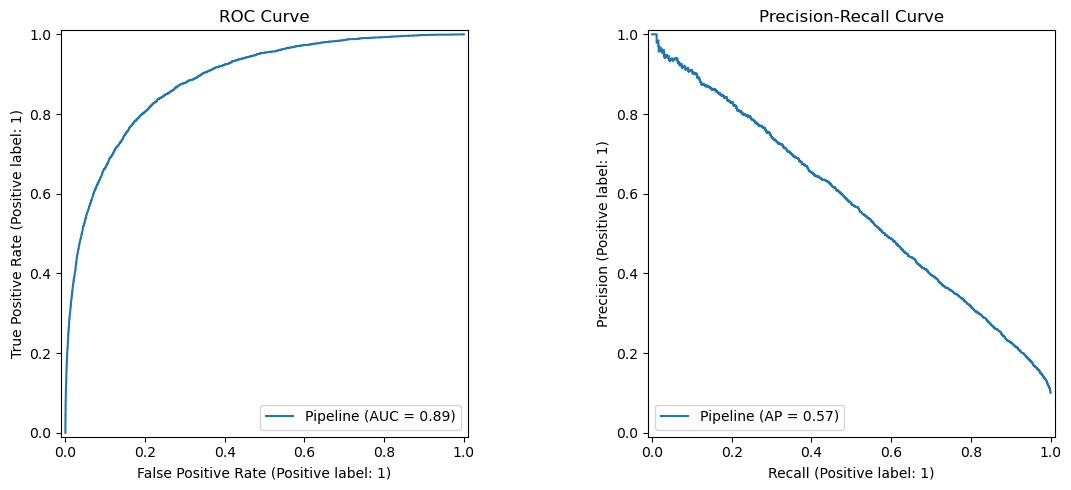

In [254]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
RocCurveDisplay.from_estimator(best_model, df_test_flagged, y_test, ax=ax1)
ax1.set_title("ROC Curve")

# Precision-Recall curve
PrecisionRecallDisplay.from_estimator(best_model, df_test_flagged, y_test, ax=ax2)
ax2.set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [257]:
import pandas as pd

# If best_model is a pipeline, get the final estimator
if hasattr(best_model, 'named_steps'):
    xgb_model = best_model.named_steps['xgbclassifier']  # adjust if your step name is different
else:
    xgb_model = best_model

# Create a DataFrame of feature importances
feature_importances_df = pd.DataFrame({
    'feature': df_train_flagged.columns,  # make sure columns match training
    'importance': xgb_model.feature_importances_
})

# Sort by importance descending
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

feature_importances_df.head(40)  # show top 20


,feature,importance
0,var_81,0.011454
1,var_139,0.010657
2,var_110,0.007735
3,var_12,0.007406
4,var_146,0.007074
5,var_6,0.007024
6,var_53,0.006898
7,var_26,0.006887
8,var_109,0.006876
9,var_80,0.006655


# Hyperparameter tuning 

In [223]:
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
import xgboost as xgb

# Base model
xgb_model = xgb.XGBClassifier(
    n_jobs=-1,
    random_state=42
)

# Parameter distributions
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],          # row sampling
    'colsample_bytree': [0.6, 0.8, 1.0],   # column sampling
    'reg_alpha': [0, 0.01, 0.1],           # L1 regularization
    'reg_lambda': [1, 1.5, 2],             # L2 regularization
    'min_child_weight': [1, 5, 10],        # minimum sum of instance weight per child
    'gamma': [0, 0.1, 0.5]                 # minimum loss reduction to make a split
}

# Stratified CV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Halving search with n_estimators as resource
halving_search = HalvingRandomSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    factor=3,                     # reduce candidates by ~1/3 each round
    resource='n_estimators',      # grow number of trees instead of samples
    min_resources=50,             # start with 50 trees
    max_resources=500,            # allow up to 500 trees
    scoring='average_precision',  # PR-AUC is good for imbalance
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=3
)

# Fit
halving_search.fit(df_train, y_train)

# Results
print("Best params:", halving_search.best_params_)
print("Best Average Precision:", halving_search.best_score_)

best_model = halving_search.best_estimator_


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 50
max_resources_: 500
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 50
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------
iter: 1
n_candidates: 4
n_resources: 150
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 2
n_candidates: 2
n_resources: 450
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0, 'n_estimators': 450}
Best Average Precision: 0.5758054590988154


In [224]:
best_model.save_model("best_xgb_model.json")